In [2]:
import requests
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ticker='AAPL'
raw_data = yf.download(ticker, period="1y", interval="1d")


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
raw_data.to_csv('data.csv')
df = pd.read_csv('data.csv')

In [5]:
df.head(8)

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2024-02-26,180.30862426757812,181.90109579673225,179.80101134340092,181.38355052297356,40867400
3,2024-02-27,181.77169799804688,183.05562869813585,178.71611879819,180.24888975946536,54318900
4,2024-02-28,180.5673828125,182.25939032452453,179.28345207788615,181.6522565198894,48953900
5,2024-02-29,179.90054321289062,181.71199718953457,178.6862755375109,180.41810366151438,136682600
6,2024-03-01,178.81565856933594,179.68156498512658,176.54637506189474,178.70617492699984,73488000
7,2024-03-04,174.277099609375,176.0686281128373,172.9732433768994,175.3221528407019,81510100


In [6]:
df = df.drop([0, 1]).reset_index(drop=True)
df.head()

,Price,Close,High,Low,Open,Volume
0,2024-02-26,180.30862426757812,181.90109579673225,179.80101134340092,181.38355052297356,40867400
1,2024-02-27,181.77169799804688,183.05562869813585,178.71611879819,180.24888975946536,54318900
2,2024-02-28,180.5673828125,182.25939032452453,179.28345207788615,181.6522565198894,48953900
3,2024-02-29,179.90054321289062,181.71199718953457,178.6862755375109,180.41810366151438,136682600
4,2024-03-01,178.81565856933594,179.68156498512658,176.54637506189474,178.70617492699984,73488000


In [7]:
df = df.rename(columns={'Price': 'DateOfStock'})

In [8]:
df['Year'] = df['DateOfStock'].str.split('-').str[0]
df['Month'] = df['DateOfStock'].str.split('-').str[1]
df['Day'] = df['DateOfStock'].str.split('-').str[2]
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Day'] = df['Day'].astype(int)


In [10]:
df.drop(['DateOfStock'], axis=1, inplace=True)

In [14]:
df[['Close', 'Open', 'High', 'Low']] = df[['Close', 'Open', 'High', 'Low']].astype(float)
df['Volume'] = df['Volume'].astype(int)


In [16]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
Year      0
Month     0
Day       0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   250 non-null    float64
 1   High    250 non-null    float64
 2   Low     250 non-null    float64
 3   Open    250 non-null    float64
 4   Volume  250 non-null    int32  
 5   Year    250 non-null    int32  
 6   Month   250 non-null    int32  
 7   Day     250 non-null    int32  
dtypes: float64(4), int32(4)
memory usage: 11.8 KB


In [18]:
df.describe()

,Close,High,Low,Open,Volume,Year,Month,Day
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.000000,250.000000
mean,213.706099,215.580760,211.556061,213.420844,5.680030e+07,2024.140000,6.568000,15.752000
std,25.976146,26.062883,25.550916,25.812333,3.129893e+07,0.347683,3.428761,8.757928
min,164.224564,165.617978,163.308889,164.572913,2.323470e+07,2024.000000,1.000000,1.000000
25%,189.804588,191.553710,188.912591,190.175838,4.047068e+07,2024.000000,4.000000,8.000000
50%,223.084549,225.362221,221.100184,223.686215,4.943365e+07,2024.000000,7.000000,16.000000
75%,230.874371,232.675403,228.204300,230.381708,6.263040e+07,2024.000000,10.000000,23.000000
max,258.735504,259.814335,257.347047,257.906429,3.186799e+08,2025.000000,12.000000,31.000000


In [23]:
df.to_csv('data_preprocessed.csv')
df_updated = pd.read_csv('data_preprocessed.csv')

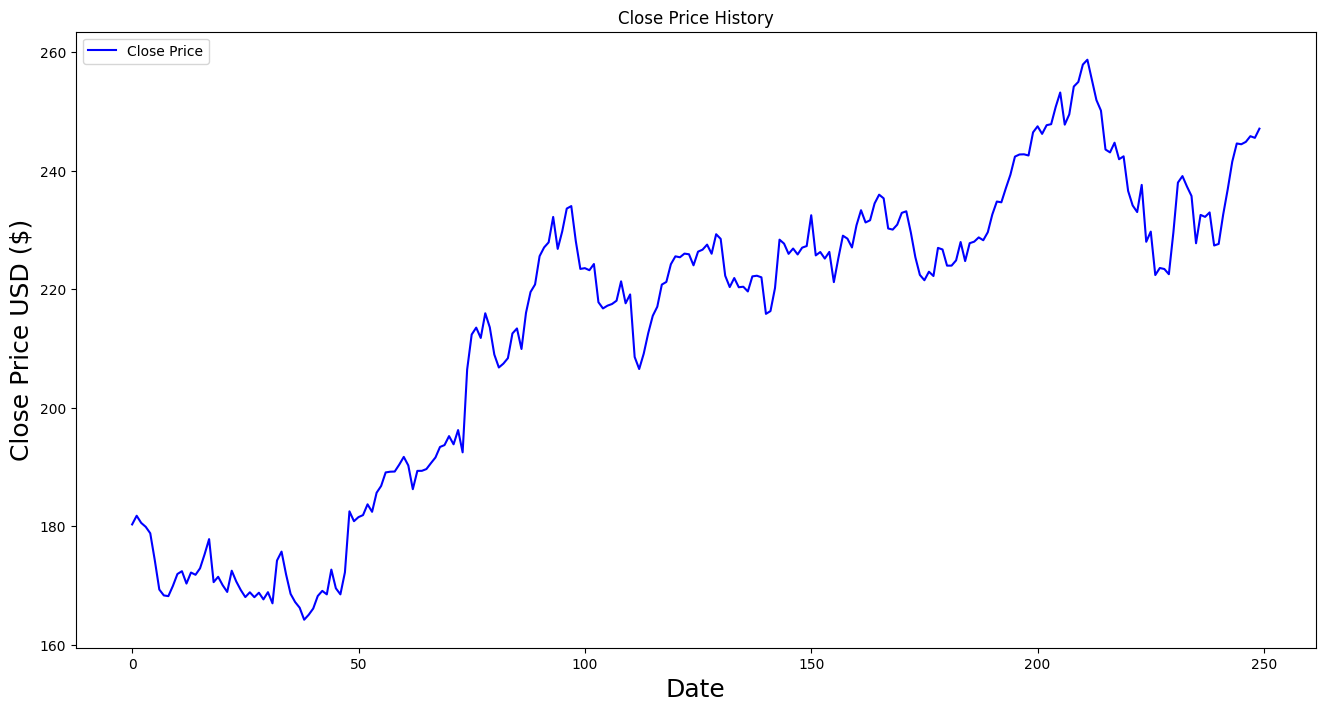

In [26]:
plt.figure(figsize=(16, 8))
plt.title('Close Price History')
plt.plot(df_updated.index,df_updated['Close'], color='blue',label='Close Price history')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.legend(['Close Price'], loc='upper left')
plt.show()

In [ ]:
# Here we are calculating the Simple Moving Average for 5 and 10 days
# And also prevois first 5 and 10 days will be NaN and this is not fair
df_updated['SME_5']=df_updated['Close'].rolling(window=5).mean()
df_updated['SME_10']=df_updated['Close'].rolling(window=10).mean()

In [ ]:
# Here based on span factor we are calculating the Exponential Moving Average for 5 and 10 days
df_updated['EMA_5'] = df_updated['Close'].ewm(span=5, adjust=False).mean()
df_updated[['EMA_5']]

,EMA_5
0,180.308624
1,180.796316
2,180.720005
3,180.446851
4,179.903120
...,...
245,240.600440
246,242.023625
247,243.292417
248,244.044946


In [ ]:
df_updated['Daily Return'] = df_updated['Close'].pct_change()

0           NaN
1      0.008114
2     -0.006625
3     -0.003693
4     -0.006030
         ...   
245   -0.000531
246    0.001636
247    0.003920
248   -0.001139
249    0.006312
Name: Daily Return, Length: 250, dtype: float64

In [37]:
df_updated.dropna(inplace=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
